### Analysis of Compton scattering

We aim to find the Compton wavelength using the slope a linear fit between $\Delta \lambda$ and $(1-cos\theta)$ for the scattering targets Aluminum and Brass separately. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable

+-----------------------------------+
|             Input Data            |
+---+-------+-------+-------+-------+
| i |   x   |   y   |   x²  |   xy  |
+---+-------+-------+-------+-------+
| 1 |  0.0  | 0.019 |  0.0  |  0.0  |
| 2 | 0.134 | 0.023 | 0.018 | 0.003 |
| 3 | 0.293 | 0.027 | 0.086 | 0.008 |
| 4 |  0.5  | 0.031 |  0.25 | 0.016 |
| 5 |  1.0  | 0.044 |  1.0  | 0.044 |
| 6 |  1.5  | 0.058 |  2.25 | 0.087 |
| Σ | 3.427 | 0.202 | 3.604 | 0.158 |
+---+-------+-------+-------+-------+ 

+-----------------------------------------+
|     Fit Results & Statistical Errors    |
+------------------+--------+-------------+
|    Parameter     | Value  | Uncertainty |
+------------------+--------+-------------+
|    Slope (a₁)    | 0.0258 |   ±0.0004   |
|  Intercept (a₀)  | 0.0190 |   ±0.0003   |
| σ_y (Std. Error) | 0.0006 |             |
|    Δ (delta)     | 9.8790 |             |
+------------------+--------+-------------+ 

+--------------------------------+
|   Measured vs Fitted Valu

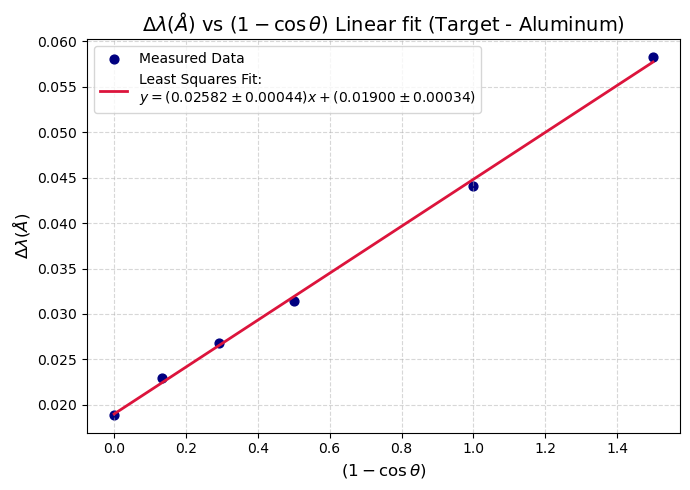

In [3]:
E = np.array([656.4,541.4,462.3,394.8,281.2,213.0])
E = E * 1.60218e-16  # Convert keV to Joules
h = 6.62607015e-34  
c = 3.0e8  
A = np.array([0,30,45,60,90,120])
x = 1 - np.cos(np.radians(A))
y = (h*c/E)*1e10  # Convert to Angstroms
n = len(x)

table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 3), round(y[i], 3), round(x[i]**2, 3), round(x[i]*y[i], 3)])
table_data.add_row(["Σ", round(np.sum(x), 3), round(np.sum(y), 3), round(np.sum(x**2), 3), round(np.sum(x*y), 3)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.4f}", f"±{sigma_a1:.4f}"])
results.add_row(["Intercept (a₀)", f"{a0:.4f}", f"±{sigma_a0:.4f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.4f}", ""])
results.add_row(["Δ (delta)", f"{delta:.4f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 3), round(yi, 3), round(yfi, 3)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(7,5))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1:.5f} \pm {sigma_a1:.5f})x + ({a0:.5f} \pm {sigma_a0:.5f})$')
plt.xlabel(r"$(1 - \cos\theta)$", fontsize=12)
plt.ylabel(r"$\Delta \lambda (\AA)$", fontsize=12)
plt.title(r"$\Delta \lambda (\AA)$ vs $(1 - \cos\theta)$ Linear fit (Target - Aluminum)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

+-----------------------------------+
|             Input Data            |
+---+-------+-------+-------+-------+
| i |   x   |   y   |   x²  |   xy  |
+---+-------+-------+-------+-------+
| 1 |  0.0  | 0.019 |  0.0  |  0.0  |
| 2 | 0.134 | 0.023 | 0.018 | 0.003 |
| 3 | 0.293 | 0.027 | 0.086 | 0.008 |
| 4 |  0.5  | 0.031 |  0.25 | 0.016 |
| 5 |  1.0  | 0.044 |  1.0  | 0.044 |
| 6 |  1.5  | 0.059 |  2.25 | 0.088 |
| Σ | 3.427 | 0.203 | 3.604 | 0.159 |
+---+-------+-------+-------+-------+ 

+-----------------------------------------+
|     Fit Results & Statistical Errors    |
+------------------+--------+-------------+
|    Parameter     | Value  | Uncertainty |
+------------------+--------+-------------+
|    Slope (a₁)    | 0.0262 |   ±0.0006   |
|  Intercept (a₀)  | 0.0189 |   ±0.0005   |
| σ_y (Std. Error) | 0.0008 |             |
|    Δ (delta)     | 9.8790 |             |
+------------------+--------+-------------+ 

+--------------------------------+
|   Measured vs Fitted Valu

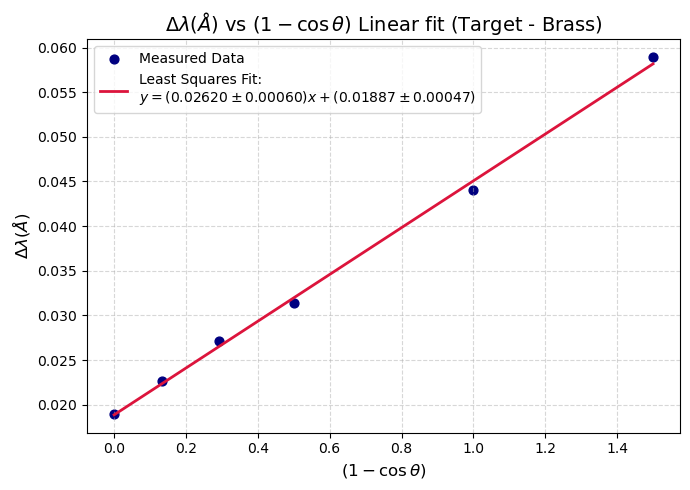

In [4]:
E = np.array([655.8,548.1,457.2,395.8,281.6,210.6])
E = E * 1.60218e-16  # Convert keV to Joules
h = 6.62607015e-34  
c = 3.0e8  
A = np.array([0,30,45,60,90,120])
x = 1 - np.cos(np.radians(A))
y = (h*c/E)*1e10  # Convert to Angstroms
n = len(x)

table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 3), round(y[i], 3), round(x[i]**2, 3), round(x[i]*y[i], 3)])
table_data.add_row(["Σ", round(np.sum(x), 3), round(np.sum(y), 3), round(np.sum(x**2), 3), round(np.sum(x*y), 3)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.4f}", f"±{sigma_a1:.4f}"])
results.add_row(["Intercept (a₀)", f"{a0:.4f}", f"±{sigma_a0:.4f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.4f}", ""])
results.add_row(["Δ (delta)", f"{delta:.4f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 3), round(yi, 3), round(yfi, 3)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(7,5))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1:.5f} \pm {sigma_a1:.5f})x + ({a0:.5f} \pm {sigma_a0:.5f})$')
plt.xlabel(r"$(1 - \cos\theta)$", fontsize=12)
plt.ylabel(r"$\Delta \lambda (\AA)$", fontsize=12)
plt.title(r"$\Delta \lambda (\AA)$ vs $(1 - \cos\theta)$ Linear fit (Target - Brass)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
def KN_Formula(theta_deg):
    r0 = 2.818e-15  # Classical electron radius 
    E0 = 662.0      
    mc2 = 511.0     
    gamma = E0 / mc2

    theta_rad = np.radians(theta_deg)
    ctheta = np.cos(theta_rad)
    
    term1 = (r0**2) * ((1 + ctheta**2) / 2)
    term2 = 1 / (1 + gamma * (1 - ctheta))**2
    term3 = (gamma**2 * (1 - ctheta)**2)/((1 + ctheta**2) * (1 + gamma * (1 - ctheta)))
    dsdo = term1 * term2 * ( term3 + 1 )
    
    return dsdo

angles = [0, 30, 45, 60, 90, 120]

print(f"{'Angle (deg)':<12} | {'dSigma/dOmega (m^2/sr)':<25}")
print("-" * 40)

for angle in angles:
    cross_section = KN_Formula(angle)
    print(f"{angle:<12} | {cross_section:.4e}")

Angle (deg)  | dSigma/dOmega (m^2/sr)   
----------------------------------------
0            | 7.9411e-30
30           | 5.1192e-30
45           | 3.3477e-30
60           | 2.2004e-30
90           | 1.3045e-30
120          | 1.1610e-30


In [ ]:
I1 = np.array([153.23,1.77,1.404,0.924,0.802,0.670])      # count rates I_i for Aluminum
I2 = np.array([79.79,3.156,2.01,1.606,1.156,0.398])     # count rates I_i for Brass
sigma = np.array([7.9411,5.1192,3.3477,2.2004,1.3045,1.1610])  # theoretical sigma_i = dσ/dΩ
t = np.array([100,500,500,500,500,500])      # measurement times t_i
n = len(I1)

delta_C1 = (1/n) * np.sqrt(np.sum(I1 / (sigma**2 * t)))
print(delta_C1)
delta_C2 = (1/n) * np.sqrt(np.sum(I2 / (sigma**2 * t)))
print(delta_C2)

0.02738748945146747
0.02099267992173254
